# Return curves of each option and env reward

In [66]:
# get data - download and store locally 
import wandb
import os
from dotenv import load_dotenv
# load environment variables from .env file
load_dotenv()
# use .env for the api key
api_key =  os.getenv("WANDB_API_KEY")
api = wandb.Api(api_key=api_key)
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/g304pm83") 
# run = api.run("raban-emunds-tu-darmstadt/uncategorized/runs/4nimiw1j") 
# run = api.run("raban-emunds-tu-darmstadt/SymbolicOptions/runs/7vwud27u") 

In [67]:
import pandas as pd
import numpy as np

# Seaquest (not multiple seeds yet)
seaquest_run_ids = {
    "pqn": "ypcp0qqv",
    "hpqn": "oibui3oi",
    "llm": "5ifcs2l8",
    "comb": "sdlmestp",
    "modifs": "3bf8l262"
}

seaquest_runs = {
    run_id: f"raban-emunds-tu-darmstadt/SymbolicOptions/runs/{run_hash}" for run_id , run_hash in seaquest_run_ids.items()
}

def get_algorithm_from_name(name):
    if "llm" in name:
        return "Fixed meta-policy"
    elif "comb" in name:
        return "Soft meta-policy"
    elif "hier" in name:
        return "HPQN"
    if "pqn" in name:
        return "PQN"
    else:
        return "Unknown"

data = []
for run in seaquest_runs:
    run = api.run(seaquest_runs[run])
    # run_data = run.history(keys=["returned_episode_env_returns", "returned_episode_returns_0",
    #                              "returned_episode_returns_1", "returned_episode_returns_2",])
    run_data_full = run.history()
    seeds = list(set([key.split("/")[0] for key in run_data_full.keys() if "rng" in key]))
    key_list = ["returned_episode_env_returns", "returned_episode_returns_0", "returned_episode_returns_1", "returned_episode_returns_2", "test/returned_episode_env_returns"]
    key_list = [seed + "/" + key for seed in seeds for key in key_list]
    key_list.append("_step")
    run_data = run_data_full.loc[:, key_list]

    x_data = run_data["_step"].to_numpy() / 1000
    def get_seed_data(seed):
        env_ret = run_data[seed + "/returned_episode_env_returns"].to_numpy()
        test_env_ret = run_data[seed + "/test/returned_episode_env_returns"].to_numpy()
        shoot_enemies_ret = run_data[seed + "/returned_episode_returns_0"].to_numpy()
        shoot_enemies_ret = (shoot_enemies_ret - shoot_enemies_ret.min()) / shoot_enemies_ret.max()  # normalize
        collect_divers_ret = run_data[seed + "/returned_episode_returns_1"].to_numpy()
        collect_divers_ret = (collect_divers_ret - collect_divers_ret.min()) / collect_divers_ret.max() # normalize 
        surface_ret = run_data[seed + "/returned_episode_returns_2"].to_numpy()
        surface_ret = (surface_ret - surface_ret.min()) / surface_ret.max()  # normalize
        return env_ret, test_env_ret, shoot_enemies_ret, collect_divers_ret, surface_ret
    all_data = np.array([get_seed_data(seed) for seed in seeds])

    row = {
        "run_id": run.id,
        "run_name": run.name,
        "seeds": seeds, 
        "algorithm": get_algorithm_from_name(run.name),
        "x_data": x_data,
        "env_ret": all_data[:, 0],
        "test_env_ret": all_data[:, 1],
        "shoot_enemies_ret": all_data[:, 2],
        "collect_divers_ret": all_data[:, 3],
        "surface_ret": all_data[:, 4],
    }
    data.append(row)
seaquest_df = pd.DataFrame(data)

In [68]:
seaquest_df

,run_id,run_name,seeds,algorithm,x_data,env_ret,test_env_ret,shoot_enemies_ret,collect_divers_ret,surface_ret
0,ypcp0qqv,pqn_Seaquest,"[rng2467461003, rng3186719485, rng2562233961]",PQN,"[0.005, 0.016, 0.019, 0.043, 0.049, 0.081, 0.0...","[[20.17486572265625, 31.100921630859375, 34.34...","[[24.799999237060547, 24.799999237060547, 24.7...","[[0.0, 0.002786982666273085, 0.003970619218917...","[[0.022137422533720617, 0.0, 0.054846713783411...","[[0.0, 0.028913450739516747, 0.028923682260227..."
1,oibui3oi,pqn_hier_Seaquest,"[rng2467461003, rng3186719485, rng2562233961]",HPQN,"[0.04, 0.077, 0.129, 0.142, 0.144, 0.157, 0.17...","[[36.1614990234375, 53.48114013671875, 77.9649...","[[6.6741108894348145, 6.6741108894348145, 6.67...","[[0.0, 0.003645953062564371, 0.008723776146924...","[[0.0, 0.020385030063605758, 0.060056164250213...","[[0.0, 0.004166422017369211, 0.009449893663341..."
2,5ifcs2l8,pqn_hier_llm_Seaquest,"[rng2467461003, rng3186719485, rng2562233961]",Fixed meta-policy,"[0.005, 0.013, 0.017, 0.021, 0.025, 0.026, 0.0...","[[19.9652099609375, 28.808441162109375, 28.513...","[[6.6741108894348145, 6.6741108894348145, 6.67...","[[0.0, 0.003375601194252408, 0.003234752591969...","[[0.0, 0.0007804644846548089, 0.00066415682764...","[[0.0, 0.015870401196821947, 0.015900718357575..."
3,sdlmestp,pqn_hier_comb_Seaquest,"[rng2467461003, rng3186719485, rng2562233961]",Soft meta-policy,"[0.002, 0.009, 0.028, 0.058, 0.089, 0.097, 0.0...","[[0.000152587890625, 27.13165283203125, 36.197...","[[6.6741108894348145, 6.6741108894348145, 6.67...","[[0.03282559125295652, 0.0, 0.0060236076293836...","[[0.21441181501912002, 0.0, 0.0088924728004214...","[[0.0, 0.58044626765977, 0.5812193551510718, 0..."
4,3bf8l262,pqn_hier_llm_modifs_Seaquest,"[rng2467461003, rng3186719485, rng2562233961]",Fixed meta-policy,"[0.047, 0.066, 0.072, 0.078, 0.083, 0.108, 0.1...","[[40.28076171875, 49.139862060546875, 52.58056...","[[0.18536241352558136, 0.18536241352558136, 0....","[[0.0, 0.0045364017204658725, 0.00630216439958...","[[0.0, 0.007119603422044759, 0.007606614764709...","[[5.014215568067504e-05, 0.001311786141611632,..."


In [69]:
# plot using plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from tueplots import bundles
from matplotlib import cm


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


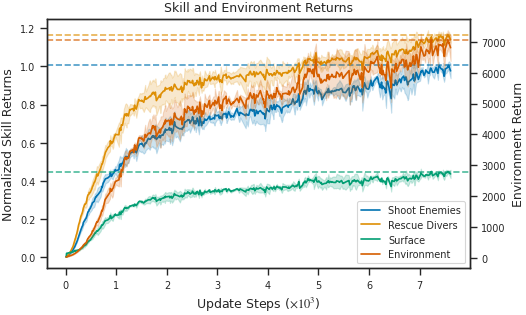

In [70]:
def single_run_plot(df, run_name, option_names, labels):
    # colors = cm.get_cmap("tab10")
    row = df[df["run_name"] == run_name].iloc[0]

    # sns.set_context("paper")
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        # remove grid
        fig, ax1 = plt.subplots()
        x_data = row["x_data"]
        for i, (option, label) in enumerate(zip(option_names, labels)):
            option_mean = row[option].mean(axis=0)
            option_std = row[option].std(axis=0)
            ax1.plot(x_data, option_mean, label=label, color=colors[i], zorder=1)
            ax1.fill_between(x_data, option_mean - option_std, option_mean + option_std, color=colors[i], alpha=0.2, zorder=0)
            ax1.axhline(max(option_mean), color=colors[i], linestyle="--", alpha=0.7, zorder=1)
        # ax1.plot(x_data, shoot_enemies_ret, label="Shoot Enemies", color=colors[0], zorder=1) 
        # ax1.plot(x_data, collect_divers_ret, label="Rescue Divers", color=colors[1], zorder=1)
        # ax1.plot(x_data, surface_ret, label="Surface", color=colors[2], zorder=1) 
        
        # Add dotted horizontal lines at the maximum values
        # ax1.axhline(max(shoot_enemies_ret), color=colors[0], linestyle="--", alpha=0.7, zorder=1)
        # ax1.axhline(max(collect_divers_ret), color=colors[1], linestyle="--", alpha=0.7, zorder=1)
        # ax1.axhline(max(surface_ret), color=colors[2], linestyle="--", alpha=0.7, zorder=1)
        ax1.set_xlabel("Update Steps ($\\times 10^3$)")
        ax1.set_ylabel("Normalized Skill Returns")

        # Create a second y-axis for the environment reward
        ax2 = ax1.twinx()
        env_mean = row["env_ret"].mean(axis=0)
        env_std = row["env_ret"].std(axis=0)
        ax2.plot(x_data, env_mean, label="Environment", color=colors[i+1], zorder=1)  # Brown
        ax2.fill_between(x_data, env_mean - env_std, env_mean + env_std, color=colors[i+1], alpha=0.2, zorder=0)
        ax2.axhline(max(env_mean), color=colors[i+1], linestyle="--", alpha=0.7, zorder=1)
        ax2.set_ylabel("Environment Return")
        
        # Combine legends from both axes and ensure they are drawn on top of the lines
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2)#, ncol=2)
        legend.set_zorder(2)  # Ensure the legend is drawn on top of the lines
        
        plt.title("Skill and Environment Returns")
        plt.tight_layout()
        plt.show()
# single_run_plot()
single_run_plot(seaquest_df, "pqn_hier_llm_Seaquest", ["shoot_enemies_ret", "collect_divers_ret", "surface_ret"], ["Shoot Enemies", "Rescue Divers", "Surface"])

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


/tmp/ipykernel_13382/3314293577.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were f

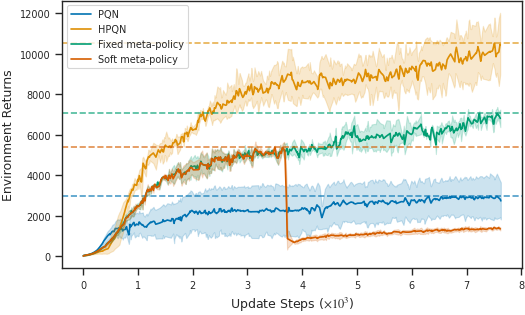

In [71]:
def comparison_plot(df, run_names):
    # Set the style
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    # Create a figure and axis
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        fig, ax = plt.subplots()
        # Plot the data
        df1 = df[df["run_name"].isin(run_names)]
        for i, row in df1.iterrows():
            # ax.plot(row["env_ret"][0], label=row["algorithm"], color=colors(i), zorder=1)
            # ax.axhline(row["env_ret"][0].max(), color=colors(i), linestyle="--", alpha=0.7, zorder=1)
            # use plt to plot data across multiple seeds
            step = row["x_data"]
            mean = np.mean(row["env_ret"], axis=0)
            std = np.std(row["env_ret"], axis=0)
            ax.plot(step, mean, label=row["algorithm"], color=colors[i], zorder=1)
            ax.fill_between(step, mean - std, mean + std, alpha=0.2, color=colors[i], zorder=1)
            ax.axhline(mean.max(), color=colors[i], linestyle="--", alpha=0.7, zorder=1)

        # Set the labels and title
        ax.set_xlabel("Update Steps ($\\times 10^3$)") 
        ax.set_ylabel("Environment Returns")
        # Add a legend
        ax.legend()
        # Show the plot
        plt.tight_layout()
        plt.show()
comparison_plot(seaquest_df, ["pqn_Seaquest", "pqn_hier_Seaquest", "pqn_hier_llm_Seaquest", "pqn_hier_comb_Seaquest"])

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Non-modified max: [1752.5267334  1645.0793457  1548.44909668], Modified max: [9078.62207031 4515.18847656 5315.75634766]
Non-modified max: [1752.5267334  1645.0793457  1548.44909668], Modified max: [9078.62207031 4515.18847656 5315.75634766]
Non-modified max: [1752.5267334  1645.0793457  1548.44909668], Modified max: [9078.62207031 4515.18847656 5315.75634766]
Non-modified max: [1752.5267334  1645.0793457  1548.44909668], Modified max: [9078.62207031 4515.18847656 5315.75634766]


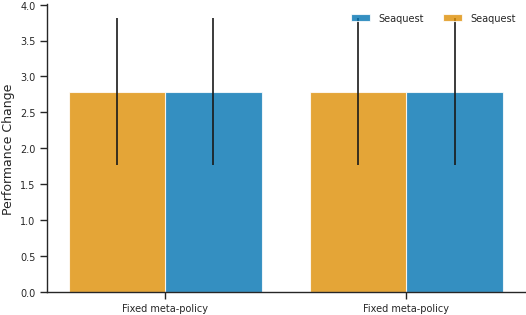

In [73]:
# What about distribution shifts? How do they handle them?

def distribution_shift_plot(df, games, algos):
    sns.set_theme(context="paper", style="ticks")
    colors = sns.color_palette("colorblind")
    with plt.rc_context(bundles.neurips2024(usetex=False)):
        width = 0.4  # narrower bars to fit more
        fig, ax = plt.subplots()

        x = np.arange(len(algos))  # one x-tick per algorithm

        # For each game and mod condition, plot bars offset from center
        for i, game in enumerate(games):
            perf_change_means = []
            perf_change_stds = []

            for algo in algos:
                # Get performance change = (modified_max - original_max) / original_max
                # Non-modified
                non_mod = df[df["run_name"] == f"{algo}_{game}"]["test_env_ret"].iloc[0]
                non_mod_max = non_mod.max(axis=1) # (n_seeds,)

                # Modified
                mod = df[df["run_name"] == f"{algo}_modifs_{game}"]["test_env_ret"].iloc[0]
                mod_max = mod.max(axis=1) # (n_seeds,)
                print(f"Non-modified max: {non_mod_max}, Modified max: {mod_max}")

                perf_change = (mod_max - non_mod_max) / non_mod_max # (n_seeds,)
                perf_change_mean = perf_change.mean()
                perf_change_std = perf_change.std()
                perf_change_means.append(perf_change_mean)
                perf_change_stds.append(perf_change_std)

            # Shift bars to the left and right based on game index
            if i % 2 == 0:
                pos = x + width/2
            else:
                pos = x - width/2
            ax.bar(pos, perf_change_means, yerr=perf_change_stds, width=width, 
                label=f"{game}", color=colors[i], alpha=0.8)

        ax.set_xticks(x)
        algo_names = [get_algorithm_from_name(algo) for algo in algos]
        ax.set_xticklabels(algo_names)
        ax.set_ylabel("Performance Change")
        # ax.set_title("Performance Change under Distribution Shift")
        ax.legend(frameon=False, ncol=2)
        sns.despine()
        plt.tight_layout()
        plt.show()


combined_df = seaquest_df.copy()
combined_df["game"] = "Seaquest"
combined_df2 = seaquest_df.copy()
combined_df2["game"] = "Seaquest"
both_df = pd.concat([combined_df, combined_df2], ignore_index=True)
# distribution_shift_plot(combined_df, ["Seaquest"], ["pqn_hier_llm"])
# This is what we want to plot later
# distribution_shift_plot(both_df, ["Seaquest", "Kangaroo"], ["pqn", "pqn_hier", "pqn_hier_llm", "pqn_hier_comb"])
distribution_shift_plot(both_df, ["Seaquest", "Seaquest"], ["pqn_hier_llm", "pqn_hier_llm"])
        